

---

PCA : PRINCIPAL COMPONENT ANALYSIS

---



**WORK FLOW**

```
Raw Data
   ↓
Standardization
   ↓
PCA
   ↓
Scree Plot
   ↓
Elbow Method
   ↓
K-Means
   ↓
Visualization
   ↓
Insights
```






**Case Study 1: Dimensionality Reduction using PCA on Iris Dataset**

The Iris dataset contains 150 samples with 4 features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Target variable:
- Setosa
- Versicolor
- Virginica

**Objective**
Reduce dataset from 4 dimensions → 2 dimensions using PCA

Compare:
- Original Data (Sepal Length vs Width)
- PCA Data (PC1 vs PC2)
- Analyze explained variance

In [1]:
# Step 1 - Import Lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Step 2 - Load data

iris = load_iris()
X = iris.data
y = iris.target

In [3]:
# Step 3 - Scaling

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

In [4]:
# Step 4 - PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

In [9]:
# Step 5 - Original columns
original_df = pd.DataFrame(data=X[:,:2],columns=['Sepal Length','Sepal Width'])
original_df['Species'] = y

In [10]:
# PC Columns
pca_df = pd.DataFrame(data=X_pca,columns=['PC1','PC2'])
pca_df['Species'] = y

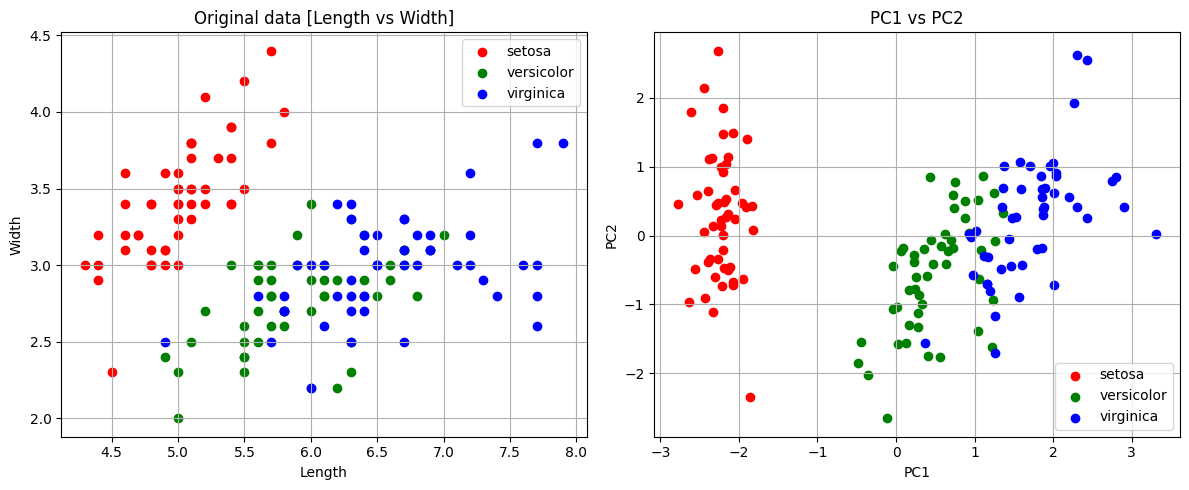

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
colors=['red','green','blue']
species = iris.target_names

for i,color in enumerate(colors):
  plt.scatter(
      original_df.loc[original_df['Species']==i,'Sepal Length'],
      original_df.loc[original_df['Species']==i,'Sepal Width'],
      c=color,label=species[i]
  )


plt.title('Original data [Length vs Width]')
plt.xlabel('Length')
plt.ylabel('Width')
plt.legend()
plt.grid()


plt.subplot(1,2,2)
colors=['red','green','blue']
species = iris.target_names

for i,color in enumerate(colors):
  plt.scatter(
      pca_df.loc[pca_df['Species']==i,'PC1'],
      pca_df.loc[pca_df['Species']==i,'PC2'],
      c=color,label=species[i]
  )


plt.title('PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [15]:
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio :",explained_variance)

Explained Variance Ratio : [0.72962445 0.22850762]


**CASE STUDY 2:- Customer Segmentation using PCA & K-Means**

An online retailer wants to segment customers but does not have labeled data.

Dataset Features:
- Annual Income ($1000s)
- Spending Score (1–100)
- Frequency of Purchase
- Average Cart Value

Objectives:-

1. Standardize the data
2. Apply PCA (reduce 4 → 2 dimensions)
3. Use Scree Plot (explained variance)
4. Use Elbow Method (find optimal K)
5. Apply K-Means clustering
6. Visualize:
- PCA-based clusters
- Original data clusters
- Interpret customer segments

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [17]:
np.random.seed(42)

num_customers = 200

customer_data = pd.DataFrame({
 'Annual Income ($1000s)': np.random.randint(20,120,num_customers),
 'Spending Score (1-100)': np.random.randint(1,101,num_customers),
 'Frequency of Purchase': np.random.randint(1,20,num_customers),
 'Average Cart Value': np.random.randint(50,500,num_customers)
})

In [18]:
scaled_data = StandardScaler().fit_transform(customer_data)

In [19]:
pca = PCA(n_components=2)
pca_df = pd.DataFrame(pca.fit_transform(scaled_data), columns=['PC1','PC2'])

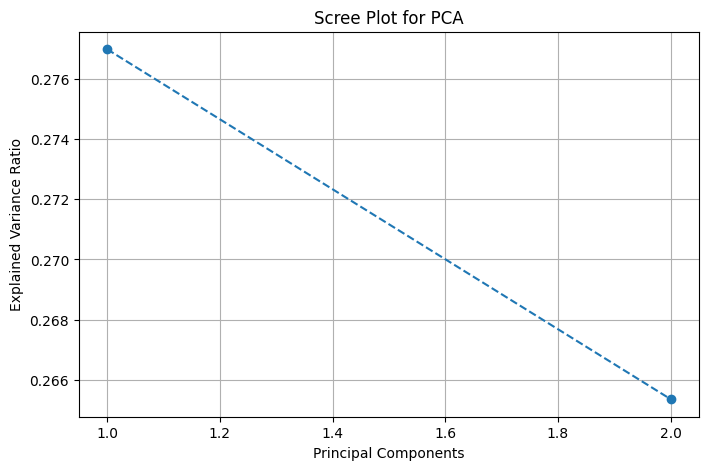

In [20]:
plt.figure(figsize=(8,5))
plt.plot(range(1,3), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot for PCA')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid()
plt.show()

In [21]:
inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(pca_df)
    inertia.append(model.inertia_)

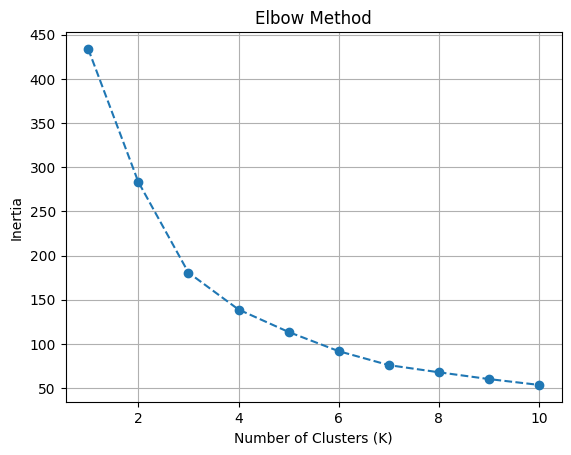

In [22]:
plt.plot(range(1,11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

In [24]:
optimal_k = 4

In [25]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
pca_df['Cluster'] = kmeans.fit_predict(pca_df)

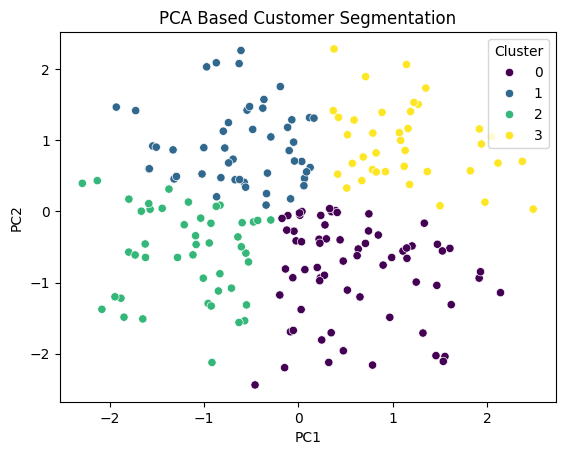

In [26]:
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('PCA Based Customer Segmentation')
plt.show()

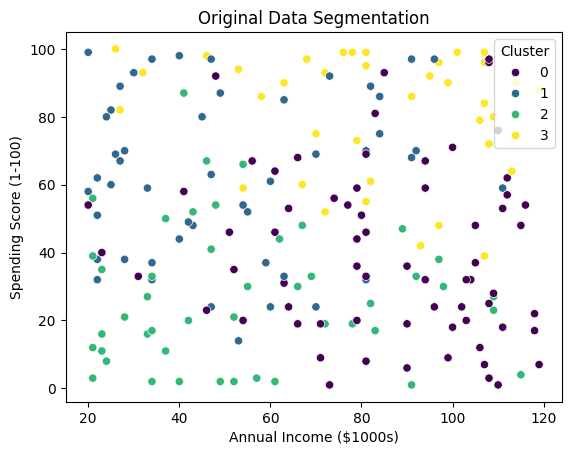

In [27]:
sns.scatterplot(data=customer_data,
                x='Annual Income ($1000s)',
                y='Spending Score (1-100)',
                hue=pca_df['Cluster'],
                palette='viridis')
plt.title('Original Data Segmentation')
plt.show()

In [29]:
customer_data['Cluster'] = pca_df['Cluster']

Why PCA before K-Means?
Because:
- Reduces noise
- Improves clustering
- Makes visualization easier



